# PointNet++ baseline

Простой baseline на вершинах 3D-мешей.

## 1. Данные

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

ROOT = Path('.')
TRAIN_DIR = ROOT / 'train (2)' / 'train'

train = pd.read_csv(ROOT / 'train(1).csv')
target_columns = train.columns.drop('item_id').tolist()

print(train.shape)
print(target_columns)

(8964, 12)
['abstract', 'artifacts', 'intersection', 'lowpoly', 'noisy', 'open', 'partial', 'scale', 'set', 'simple', 'quality']


## 2. Разбиение данных

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

train_val_index, test_index = next(
    splitter.split(train, train[target_columns])
)

train_val_df = train.iloc[train_val_index].reset_index(drop=True)
test_df = train.iloc[test_index].reset_index(drop=True)

splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.1765,
    random_state=43
)

train_index, val_index = next(
    splitter.split(train_val_df, train_val_df[target_columns])
)

train_df = train_val_df.iloc[train_index].reset_index(drop=True)
val_df = train_val_df.iloc[val_index].reset_index(drop=True)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Internal test:', len(test_df))

Train: 6259
Validation: 1361
Internal test: 1344


## 3. Dataset

Для каждого объекта берём 512 вершин и нормализуем их координаты.

In [4]:
NUM_POINTS = 512


class PointCloudDataset(Dataset):
    def __init__(self, dataframe, training=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with np.load(TRAIN_DIR / f"{row['item_id']}.npz") as mesh:
            points = mesh['vertices'].astype(np.float32)

        replace = len(points) < NUM_POINTS

        if self.training:
            point_indices = np.random.choice(
                len(points),
                NUM_POINTS,
                replace=replace
            )
        else:
            generator = np.random.default_rng(SEED + index)
            point_indices = generator.choice(
                len(points),
                NUM_POINTS,
                replace=replace
            )

        points = points[point_indices]
        points = points - points.mean(axis=0)
        points = points / (np.linalg.norm(points, axis=1).max() + 1e-8)

        target = row[target_columns].to_numpy(dtype=np.float32)

        return torch.tensor(points), torch.tensor(target)

## 4. DataLoader

In [5]:
BATCH_SIZE = 16

train_dataset = PointCloudDataset(train_df, training=True)
val_dataset = PointCloudDataset(val_df, training=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

points, targets = next(iter(train_loader))

print('Points:', points.shape)
print('Targets:', targets.shape)

Points: torch.Size([16, 512, 3])
Targets: torch.Size([16, 11])


## 5. Вспомогательные функции

Выбираем далёкие друг от друга центры и находим их ближайших соседей.

In [6]:
def take_points(points, indices):
    batch = torch.arange(points.size(0), device=points.device)
    batch = batch.view(points.size(0), *([1] * (indices.dim() - 1)))
    return points[batch, indices]


def farthest_points(xyz, count):
    batch_size, point_count, _ = xyz.shape
    selected = torch.zeros(
        batch_size,
        count,
        dtype=torch.long,
        device=xyz.device
    )
    distances = torch.full(
        (batch_size, point_count),
        1e10,
        device=xyz.device
    )

    center = xyz.mean(dim=1, keepdim=True)
    farthest = ((xyz - center) ** 2).sum(-1).argmax(-1)
    batch = torch.arange(batch_size, device=xyz.device)

    for index in range(count):
        selected[:, index] = farthest
        point = xyz[batch, farthest].unsqueeze(1)
        distance = ((xyz - point) ** 2).sum(-1)
        distances = torch.minimum(distances, distance)
        farthest = distances.argmax(-1)

    return selected


def nearest_points(xyz, centers, count):
    distances = torch.cdist(centers, xyz)
    return distances.topk(count, largest=False).indices

## 6. Set Abstraction

In [7]:
class SetAbstraction(nn.Module):
    def __init__(self, center_count, neighbor_count, input_size, output_sizes):
        super().__init__()

        self.center_count = center_count
        self.neighbor_count = neighbor_count

        layers = []

        for output_size in output_sizes:
            layers += [
                nn.Conv2d(input_size, output_size, 1),
                nn.BatchNorm2d(output_size),
                nn.ReLU()
            ]
            input_size = output_size

        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz, features=None):
        center_indices = farthest_points(xyz, self.center_count)
        centers = take_points(xyz, center_indices)

        neighbor_indices = nearest_points(
            xyz,
            centers,
            self.neighbor_count
        )

        local_xyz = take_points(xyz, neighbor_indices)
        local_xyz = local_xyz - centers.unsqueeze(2)

        if features is None:
            local_features = local_xyz
        else:
            local_features = torch.cat([
                local_xyz,
                take_points(features, neighbor_indices)
            ], dim=-1)

        local_features = local_features.permute(0, 3, 1, 2)
        new_features = self.mlp(local_features).max(dim=-1).values

        return centers, new_features.permute(0, 2, 1)

## 7. Модель

In [8]:
class SimplePointNetPlusPlus(nn.Module):
    def __init__(self, output_size):
        super().__init__()

        self.layer1 = SetAbstraction(
            128, 32, 3, [64, 128]
        )
        self.layer2 = SetAbstraction(
            32, 32, 131, [128, 256]
        )

        self.global_layer = nn.Sequential(
            nn.Conv1d(259, 512, 1),
            nn.ReLU(),
            nn.Conv1d(512, 1024, 1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_size)
        )

    def forward(self, points):
        xyz, features = self.layer1(points)
        xyz, features = self.layer2(xyz, features)

        features = torch.cat([xyz, features], dim=-1)
        features = features.permute(0, 2, 1)
        features = self.global_layer(features).max(dim=-1).values

        return self.classifier(features)

## 8. Loss и optimizer

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimplePointNetPlusPlus(len(target_columns)).to(device)

positive = train_df[target_columns].sum().to_numpy()
negative = len(train_df) - positive
pos_weight = torch.tensor(
    negative / positive,
    dtype=torch.float32,
    device=device
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

print('Device:', device)
print('Параметров:', f'{sum(p.numel() for p in model.parameters()):,}')

Device: cpu
Параметров: 983,307


## 9. Функции обучения

In [10]:
def train_epoch():
    model.train()
    total_loss = 0

    for points, targets in train_loader:
        points = points.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        loss = criterion(model(points), targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(points)

    return total_loss / len(train_dataset)


def validate():
    model.eval()
    total_loss = 0
    all_targets = []
    all_probabilities = []

    with torch.no_grad():
        for points, targets in val_loader:
            points = points.to(device)
            targets = targets.to(device)

            logits = model(points)
            loss = criterion(logits, targets)

            total_loss += loss.item() * len(points)
            all_targets.append(targets.cpu().numpy())
            all_probabilities.append(torch.sigmoid(logits).cpu().numpy())

    return (
        total_loss / len(val_dataset),
        np.concatenate(all_targets),
        np.concatenate(all_probabilities)
    )

## 10. Метрики

In [11]:
def get_metrics(targets, probabilities):
    predictions = (probabilities >= 0.5).astype(int)

    class_f1 = f1_score(
        targets,
        predictions,
        average=None,
        zero_division=0
    )
    weighted_f1 = f1_score(
        targets[:, :10],
        predictions[:, :10],
        average='weighted',
        zero_division=0
    )
    quality_f1 = class_f1[-1]

    return {
        'macro_f1': class_f1.mean(),
        'weighted_f1': weighted_f1,
        'quality_f1': quality_f1,
        'score': (weighted_f1 + quality_f1) / 2,
        'class_f1': class_f1
    }

## 11. Обучение

In [12]:
EPOCHS = 5
MODEL_PATH = ROOT / 'best_pointnetpp.pth'

history = []
best_score = -1

for epoch in range(EPOCHS):
    train_loss = train_epoch()
    val_loss, val_targets, val_probabilities = validate()
    metrics = get_metrics(val_targets, val_probabilities)

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'score': metrics['score']
    })

    print(
        f'Epoch {epoch + 1}/{EPOCHS} | '
        f'train loss: {train_loss:.4f} | '
        f'val loss: {val_loss:.4f} | '
        f'score: {metrics["score"]:.4f}'
    )

    if metrics['score'] > best_score:
        best_score = metrics['score']
        torch.save(model.state_dict(), MODEL_PATH)
        print('Сохранена лучшая модель')

history = pd.DataFrame(history)
history

Epoch 1/5 | train loss: 1.2060 | val loss: 1.1388 | score: 0.3380
Сохранена лучшая модель
Epoch 2/5 | train loss: 1.1666 | val loss: 1.1391 | score: 0.3437
Сохранена лучшая модель
Epoch 3/5 | train loss: 1.1504 | val loss: 1.1134 | score: 0.3553
Сохранена лучшая модель
Epoch 4/5 | train loss: 1.1201 | val loss: 1.0906 | score: 0.3577
Сохранена лучшая модель
Epoch 5/5 | train loss: 1.1146 | val loss: 1.1198 | score: 0.3718
Сохранена лучшая модель


,epoch,train_loss,val_loss,score
0,1,1.205972,1.138803,0.337981
1,2,1.166573,1.139097,0.343739
2,3,1.150427,1.113435,0.355305
3,4,1.120067,1.090634,0.357667
4,5,1.114575,1.119750,0.371831


## 12. Результат

In [13]:
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device, weights_only=True)
)

val_loss, val_targets, val_probabilities = validate()
metrics = get_metrics(val_targets, val_probabilities)

result = pd.DataFrame({
    'target': target_columns,
    'F1': metrics['class_f1']
})

display(result.round(4))
print('Validation loss:', round(val_loss, 4))
print('Macro F1:', round(metrics['macro_f1'], 4))
print('Weighted F1 дефектов:', round(metrics['weighted_f1'], 4))
print('F1 quality:', round(metrics['quality_f1'], 4))
print('Score:', round(metrics['score'], 4))

,target,F1
0,abstract,0.4032
1,artifacts,0.1223
2,intersection,0.0412
3,lowpoly,0.3341
4,noisy,0.6206
5,open,0.1515
6,partial,0.1765
7,scale,0.0362
8,set,0.2788
9,simple,0.5637


Validation loss: 1.1198
Macro F1: 0.2765
Weighted F1 дефектов: 0.4299
F1 quality: 0.3138
Score: 0.3718


## 13. Графики

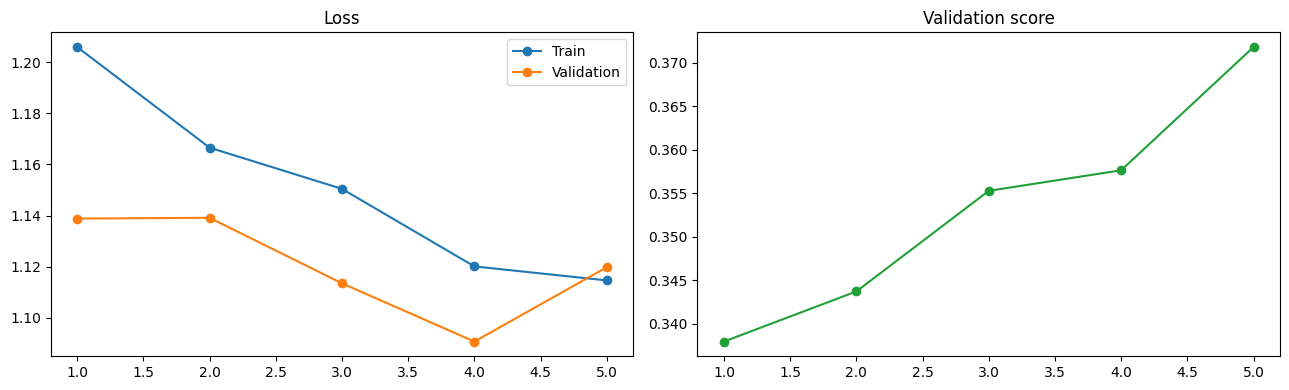

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='Train')
axes[0].plot(history['epoch'], history['val_loss'], marker='o', label='Validation')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(
    history['epoch'],
    history['score'],
    marker='o',
    color='#21A038'
)
axes[1].set_title('Validation score')

plt.tight_layout()
plt.show()